In [6]:
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg
import statsmodels.formula.api as smf

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/figS5_pv_corr')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
# fraction of cells that are place cells dense
rows = []
for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(6):

            sess = u.load_single_day(mouse,day)

            for ttype in ('fam','nov'):

                if ttype=='fam':
                    tmask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    tmask = sess.trial_info['LR']==sess.novel_arm

                trial_mat = sess.trial_matrices['F_dff'][tmask, : ,:]

                pvcorr = stx.spatial_analyses.calc_pv_corr(trial_mat)
                pvcorr[np.diag_indices_from(pvcorr)]=np.nan
                mu_pvcorr = np.nanmean(pvcorr.ravel())
                rows.append({
                    'cond': cond,
                    'mouse': mouse,
                    'day': day,
                    'nov': ttype,
                    'pvcorr': mu_pvcorr,
                })
df = pd.DataFrame(rows)

{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 2}


...

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 4}


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 5}


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


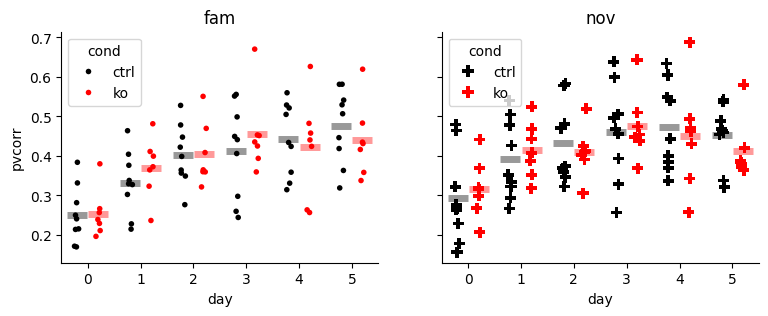

In [4]:
fig, ax = plt.subplots(1,2, figsize=[9,3], sharey=True)

for i, ttype in enumerate(('fam', 'nov')):
    tmp_df = df.loc[df['nov']==ttype]

    if ttype == 'fam':
        marker='.'
        s=8
    else:
        marker='P'
        s=8

    sns.stripplot(
        data=tmp_df,
        x='day',
        y='pvcorr',
        hue='cond',
        dodge=True,
        ax=ax[i],
        palette=['black','red'],
        hue_order=['ctrl','ko'],
        alpha=1., marker=marker, s=s,
    )

    sns.pointplot(
        data=tmp_df,
        x='day',
        y='pvcorr',
        hue='cond',
        dodge=.4,
        ax=ax[i],
        palette=['black','red'],
        hue_order=['ctrl','ko'],
        errorbar=None,
        linestyles="none",
        marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
    )
    ax[i].set_title(ttype)


for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig(figdir / "dense_pvcorr_v_days.pdf")


In [5]:
import statsmodels.formula.api as smf

df['rank_pvcorr'] = df['pvcorr'].rank()

mdl = smf.mixedlm('rank_pvcorr ~   C(day) + C(cond) + C(nov)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
===========================================================
Model:              MixedLM Dependent Variable: rank_pvcorr
No. Observations:   192     Method:             REML       
No. Groups:         16      Scale:              792.8081   
Min. group size:    12      Log-Likelihood:     -911.9563  
Max. group size:    12      Converged:          Yes        
Mean group size:    12.0                                   
-----------------------------------------------------------
               Coef.   Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------
Intercept       30.763   14.365  2.142 0.032   2.608 58.917
C(day)[T.1]     45.281    7.039  6.433 0.000  31.485 59.078
C(day)[T.2]     64.406    7.039  9.150 0.000  50.610 78.203
C(day)[T.3]     83.406    7.039 11.849 0.000  69.610 97.203
C(day)[T.4]     81.125    7.039 11.525 0.000  67.328 94.922
C(day)[T.5]     83.156    7.039 11.813 0.000  69.360 96.953
C(cond)[T.ko]   -1.291   20.372 -0.063 0.949 -41.220 38.638
C(nov)[T.nov]   13.479    4.064  3.317 0.001   5.514 21.445
Group Var     1568.115   22.822                            
===========================================================

"""

In [6]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                chi2                 P>chi2  df constraint
Intercept      [[4.586094100775237]]    0.03223238711976516              1
C(day)         [[216.5563473625399]]  8.120152751564517e-45              5
C(cond)    [[0.0040158360873920355]]     0.9494713782362024              1
C(nov)         [[11.00016624342776]]  0.0009110371589395064              1

In [7]:
# fraction of cells that are place cells dense
rows = []
for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(6):

            sess = u.load_single_day(mouse,day)

            fam_mask = sess.trial_info['LR']!=sess.novel_arm
            nov_mask = sess.trial_info['LR']==sess.novel_arm

            fam_mat = np.nanmean(sess.trial_matrices['F_dff'][fam_mask,10:,:], axis=0)
            nov_mat = np.nanmean(sess.trial_matrices['F_dff'][nov_mask, 10:, :], axis=0)

            fam_mat[np.isnan(fam_mat)]=0
            nov_mat[np.isnan(nov_mat)]=0

            corr_mat = np.zeros((fam_mat.shape[0],))
            for pos in range(fam_mat.shape[0]):
                corr_mat[pos] = np.corrcoef(np.vstack((fam_mat[pos,:], nov_mat[pos,:])))[0,1]

            rows.append({
                'cond': cond,
                'mouse': mouse,
                'day': day,
                'pvcorr': corr_mat.mean(),
            })
df = pd.DataFrame(rows)

{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '02_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 3}
{'date': '03_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 4}
{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 2}
({'date': '02_12_2020', 'scene': 'YMaze_LNovel', 

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '16_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '17_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 1, 'novel_arm': 1, 'ravel_ind': 4}
{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '16_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '17_10_2021', 'scene': 'YMaze_LNovel', 'ses

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2}


...

{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': -1, 'ravel_ind': 5}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 4}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'ses

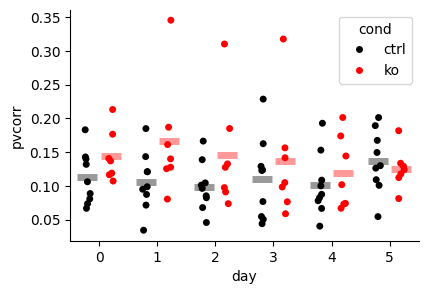

In [8]:
fig, ax = plt.subplots(figsize=[4.5,3])


sns.stripplot(
    data=df,
    x='day',
    y='pvcorr',
    hue='cond',
    dodge=True,
    ax=ax,
    palette=['black','red'],
    hue_order=['ctrl','ko'],
    alpha=1., 
)

sns.pointplot(
    data=df,
    x='day',
    y='pvcorr',
    hue='cond',
    dodge=.4,
    ax=ax,
    palette=['black','red'],
    hue_order=['ctrl','ko'],
    errorbar=None,
    linestyles="none",
    marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(figdir / "dense_acrosstttype_pvcorr_v_days.pdf")


In [9]:
df['rank_pvcorr'] = df['pvcorr'].rank()
pg.mixed_anova(data = df, dv='rank_pvcorr', within='day', between='cond', subject='mouse')

,Source,SS,DF1,DF2,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,cond,3733.714286,1,14,3733.714286,1.500734,0.240771,NaN,0.096817,NaN,NaN,NaN,NaN
1,day,3258.500000,5,70,651.700000,1.545685,0.186980,0.216206,0.099429,0.639107,False,0.112933,0.013137
2,Interaction,2383.055556,5,70,476.611111,1.130414,0.352469,NaN,0.074711,NaN,NaN,NaN,NaN


In [3]:
# fraction of cells that are place cells dense
rows = []
for mouse in sparse_mice:
    for day in range(6):
        if mouse=='SparseKO_09' and day==2:
            continue

        sess = u.load_single_day(mouse,day)
        for chan in ('channel_0', 'channel_1'):
            for ttype in ('fam','nov'):

                if ttype=='fam':
                    tmask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    tmask = sess.trial_info['LR']==sess.novel_arm

                trial_mat = sess.trial_matrices[f'{chan}_F_dff'][tmask, : ,:]
                trial_mat[np.isnan(trial_mat)]=0

                pvcorr = stx.spatial_analyses.calc_pv_corr(trial_mat)
                pvcorr[np.diag_indices_from(pvcorr)]=np.nan
                mu_pvcorr = np.nanmean(pvcorr.ravel())
                rows.append({
                    'chan': chan,
                    'mouse': mouse,
                    'day': day,
                    'ttype': ttype,
                    'pvcorr': mu_pvcorr,
                })
df = pd.DataFrame(rows)

{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1, 'ravel_ind': 0}


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2, 'ravel_ind': 1}


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3, 'ravel_ind': 2}


...

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': 14, 'novel_arm': -1, 'exp_day': 5, 'ravel_ind': 4}


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'date': '30_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 37, 'novel_arm': -1, 'exp_day': 6, 'ravel_ind': 5}


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


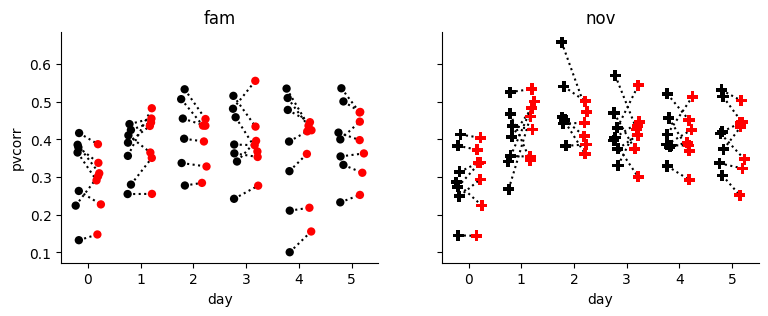

In [4]:
fig, ax = plt.subplots(1,2, figsize=[9,3], sharey=True)

for i, ttype in enumerate(('fam', 'nov')):
    tmp_df = df.loc[df['ttype']==ttype]
    if ttype == 'fam':
        marker='.'
        s=12
    else:
        marker='P'
        s=8
    sns.stripplot(
        data=tmp_df,
        x='day',
        y='pvcorr',
        hue='chan',
        dodge=True,
        ax=ax[i],
        palette=['black','red'],
        hue_order=['channel_1','channel_0'],
        alpha=1., legend=False, marker=marker, s=s,
    )

    
    ax[i].set_title(ttype)
    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig(figdir / "sparse_pvcorr_v_days.pdf")


In [7]:
df['rank_pvcorr'] = df['pvcorr'].rank()

mdl = smf.mixedlm('rank_pvcorr ~   C(day) + C(chan) + C(ttype)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:              MixedLM   Dependent Variable:   rank_pvcorr
No. Observations:   164       Method:               REML       
No. Groups:         7         Scale:                1146.8629  
Min. group size:    20        Log-Likelihood:       -793.1414  
Max. group size:    24        Converged:            Yes        
Mean group size:    23.4                                       
---------------------------------------------------------------
                      Coef.  Std.Err.   z   P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             32.973   13.195 2.499 0.012  7.110 58.836
C(day)[T.1]           50.321    9.051 5.560 0.000 32.582 68.061
C(day)[T.2]           59.095    9.490 6.227 0.000 40.495 77.695
C(day)[T.3]           51.964    9.051 5.741 0.000 34.225 69.704
C(day)[T.4]           44.107    9.051 4.873 0.000 26.368 61.847
C(day)[T.5]           47.000    9.051 5.193 0.000 29.261 64.739
C(chan)[T.channel_1]   2.049    5.289 0.387 0.698 -8.317 12.415
C(ttype)[T.nov]       12.220    5.289 2.310 0.021  1.853 22.586
Group Var            834.216   15.371                          
===============================================================

"""

In [8]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                              chi2                  P>chi2  df constraint
Intercept   [[6.2441033811516835]]    0.012460744515597434              1
C(day)      [[53.828809345360305]]  2.2726655176808405e-10              5
C(chan)    [[0.15005939930421658]]      0.6984786006709601              1
C(ttype)     [[5.338018606116357]]     0.02086517586077023              1

In [9]:

rows = []

for mouse in sparse_mice:
    for day in range(6):
        if mouse == 'SparseKO_09' and day ==2:
            continue

        sess = u.load_single_day(mouse,day)

        fam_mask = sess.trial_info['LR']!=sess.novel_arm
        nov_mask = sess.trial_info['LR']==sess.novel_arm

        for chan in ('channel_0', 'channel_1'):

            fam_mat = np.nanmean(sess.trial_matrices[f'{chan}_F_dff'][fam_mask,10:,:], axis=0)
            nov_mat = np.nanmean(sess.trial_matrices[f'{chan}_F_dff'][nov_mask, 10:, :], axis=0)

            fam_mat[np.isnan(fam_mat)]=0
            nov_mat[np.isnan(nov_mat)]=0

            corr_mat = np.zeros((fam_mat.shape[0],))
            for pos in range(fam_mat.shape[0]):
                corr_mat[pos] = np.corrcoef(np.vstack((fam_mat[pos,:], nov_mat[pos,:])))[0,1]

            rows.append({
                'chan': chan,
                'mouse': mouse,
                'day': day,
                'pvcorr': corr_mat.mean(),
            })
df = pd.DataFrame(rows)

{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1, 'ravel_ind': 0}
{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2, 'ravel_ind': 1}
{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3, 'ravel_ind': 2}
{'date': '19_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4, 'ravel_ind': 3}
{'date': '20_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 12, 'novel_arm': -1, 'exp_day': 5, 'ravel_ind': 4}
{'date': '21_11_2024', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': -1, 'exp_day': 6, 'ravel_ind': 5}
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 7, 'novel_arm': 1, 'exp_day': 1, 'ravel_ind': 0}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 23, 'novel_arm': 1, 'exp_day': 2, 'ravel_ind': 1}
{'date': '28_05_2025', 'scene': 'YMaz

/tmp/ipykernel_179374/488349261.py:16: RuntimeWarning: Mean of empty slice
  nov_mat = np.nanmean(sess.trial_matrices[f'{chan}_F_dff'][nov_mask, 10:, :], axis=0)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 3, 'ravel_ind': 2}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 22, 'novel_arm': 1, 'exp_day': 4, 'ravel_ind': 3}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 16, 'novel_arm': 1, 'exp_day': 5, 'ravel_ind': 4}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 6, 'ravel_ind': 5}
{'date': '25_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'exp_day': 1, 'ravel_ind': 0}
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 14, 'novel_arm': -1, 'exp_day': 2, 'ravel_ind': 1}
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4, 'ravel_ind': 3}
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': 14, 'novel_arm': -1, 'exp_day': 5, 'ravel_ind': 4}
{'date': '30_05_2025', 'scene': 'YMaze

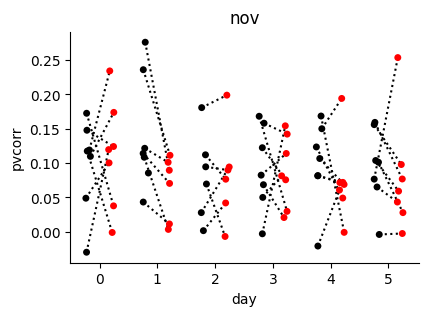

In [10]:
fig, ax = plt.subplots( figsize=[4.5,3])


sns.stripplot(
    data=df,
    x='day',
    y='pvcorr',
    hue='chan',
    dodge=True,
    ax=ax,
    palette=['black','red'],
    hue_order=['channel_1','channel_0'],
    alpha=1., legend=False,
)


ax.set_title(ttype)
for d in range(0,12,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(figdir / "sparse_acrossttype_pvcorr_v_days.pdf")


In [11]:
df['rank_pvcorr'] = df['pvcorr'].rank()
pg.rm_anova(data = df, dv='rank_pvcorr', within=['day', 'chan'], subject='mouse')

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,day,1307.083333,5,20,261.416667,0.654865,0.661390,0.571913,0.049337,0.497674
1,chan,1570.816667,1,4,1570.816667,3.880716,0.120176,0.120176,0.058707,1.000000
2,day * chan,1597.083333,5,20,319.416667,0.657540,0.659502,0.547382,0.059630,0.411347
